In [1]:
!pip install pandas numpy scikit-learn catboost matplotlib seaborn joblib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\bmaru\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from catboost import CatBoostClassifier

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\bmaru\Downloads\Medical_Insurance_Training_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (57500, 36)


,Name,Age,Gender/Sex,Location,Relationship,Hobbies,BMI,Systolic_BP,Diastolic_BP,Blood_Glucose,...,Frequent_Urination,Excessive_Thirst,Headache,Abdominal_Pain,Heartburn,Anxiety_Symptom,Depressed_Mood,Heart_Palpitations,Chief_Complaint,Medical Condition
0,Person_00001_ART,60,Female,Bengaluru,Married,"Music, Reading",28.4,142.1,86.4,119.9,...,0,0,0,0,0,0,0,1,Joint pain/stiffness,Arthritis
1,Person_00002_ART,51,Male,Pune,Married,"Photography, Gardening",27.0,142.9,86.7,107.4,...,1,0,0,0,0,0,0,0,Joint pain/stiffness,Arthritis
2,Person_00003_ART,63,Female,Kolar,Not Married,"Gardening, Walking",28.6,135.4,90.7,125.6,...,0,0,0,0,0,0,0,0,Joint pain/stiffness,Arthritis
3,Person_00004_ART,65,Female,Shivamogga,Not Married,"Running, Cycling",26.5,149.9,86.3,112.7,...,0,0,0,0,0,0,0,0,Joint pain/stiffness,Arthritis
4,Person_00005_ART,44,Male,Chennai,Married,"Yoga, Reading",26.8,145.6,85.0,97.6,...,0,1,0,0,0,0,0,0,Joint pain/stiffness,Arthritis


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Medical Condition"].value_counts())

Columns:
['Name', 'Age', 'Gender/Sex', 'Location', 'Relationship', 'Hobbies', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Blood_Glucose', 'Cholesterol', 'Vitamin_D', 'Hemoglobin', 'Creatinine', 'Respiratory_Rate', 'Heart_Rate', 'Smoking_Status', 'Physical_Activity_Minutes', 'Sleep_Hours', 'Family_History', 'Joint_Pain', 'Back_Pain', 'Fatigue', 'Cough', 'Wheezing', 'Chest_Pain', 'Frequent_Urination', 'Excessive_Thirst', 'Headache', 'Abdominal_Pain', 'Heartburn', 'Anxiety_Symptom', 'Depressed_Mood', 'Heart_Palpitations', 'Chief_Complaint', 'Medical Condition']

Missing Values:
Name                         0
Age                          0
Gender/Sex                   0
Location                     0
Relationship                 0
Hobbies                      0
BMI                          0
Systolic_BP                  0
Diastolic_BP                 0
Blood_Glucose                0
Cholesterol                  0
Vitamin_D                    0
Hemoglobin                   0
Creatinine          

In [5]:
# Target
y = df["Medical Condition"]

# Remove columns that should NOT be used for prediction
X = df.drop(
    columns=[
        "Medical Condition",
        "Name",
        "Chief_Complaint"
    ]
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X Shape: (57500, 33)
y Shape: (57500,)

Features:
['Age', 'Gender/Sex', 'Location', 'Relationship', 'Hobbies', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Blood_Glucose', 'Cholesterol', 'Vitamin_D', 'Hemoglobin', 'Creatinine', 'Respiratory_Rate', 'Heart_Rate', 'Smoking_Status', 'Physical_Activity_Minutes', 'Sleep_Hours', 'Family_History', 'Joint_Pain', 'Back_Pain', 'Fatigue', 'Cough', 'Wheezing', 'Chest_Pain', 'Frequent_Urination', 'Excessive_Thirst', 'Headache', 'Abdominal_Pain', 'Heartburn', 'Anxiety_Symptom', 'Depressed_Mood', 'Heart_Palpitations']


In [6]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Gender/Sex', 'Location', 'Relationship', 'Hobbies', 'Smoking_Status']


C:\Users\bmaru\AppData\Local\Temp\ipykernel_21748\1844633872.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [7]:
for col in categorical_columns:
    X[col] = X[col].fillna("Unknown").astype(str)

In [8]:
numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (46000, 33)
Testing Data: (11500, 33)


In [10]:
model = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=80
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_test, y_test),
    early_stopping_rounds=80
)

0:	learn: 0.4751087	test: 0.4717391	best: 0.4717391 (0)	total: 2.27s	remaining: 22m 38s
80:	learn: 0.8849565	test: 0.8740870	best: 0.8740870 (79)	total: 2m 39s	remaining: 17m
160:	learn: 0.9098696	test: 0.8927826	best: 0.8932174 (159)	total: 5m 58s	remaining: 16m 18s
240:	learn: 0.9210652	test: 0.8995652	best: 0.8997391 (234)	total: 9m 37s	remaining: 14m 20s
320:	learn: 0.9274783	test: 0.9026957	best: 0.9030435 (293)	total: 14m 58s	remaining: 13m 1s
400:	learn: 0.9319783	test: 0.9033043	best: 0.9040000 (373)	total: 22m 5s	remaining: 10m 58s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.904
bestIteration = 373

Shrink model to first 374 iterations.


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=600, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=80)

In [11]:
y_pred = model.predict(X_test).flatten()

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 90.40%


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 90.40%


In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                                        precision    recall  f1-score   support

                     Allergic Rhinitis       0.87      0.84      0.86       500
                                Anemia       1.00      1.00      1.00       500
                      Anxiety Disorder       0.95      0.95      0.95       500
                             Arthritis       0.83      0.83      0.83       500
                                Asthma       0.79      0.81      0.80       500
                                Cancer       0.98      0.98      0.98       500
                     Chronic Back Pain       0.84      0.84      0.84       500
                Chronic Kidney Disease       1.00      1.00      1.00       500
                            Depression       0.96      0.95      0.95       500
                              Diabetes       0.85      0.82      0.83       500
                   Fatty Liver Disease       0.92      0.88      0.90       500
                             Gastritis 

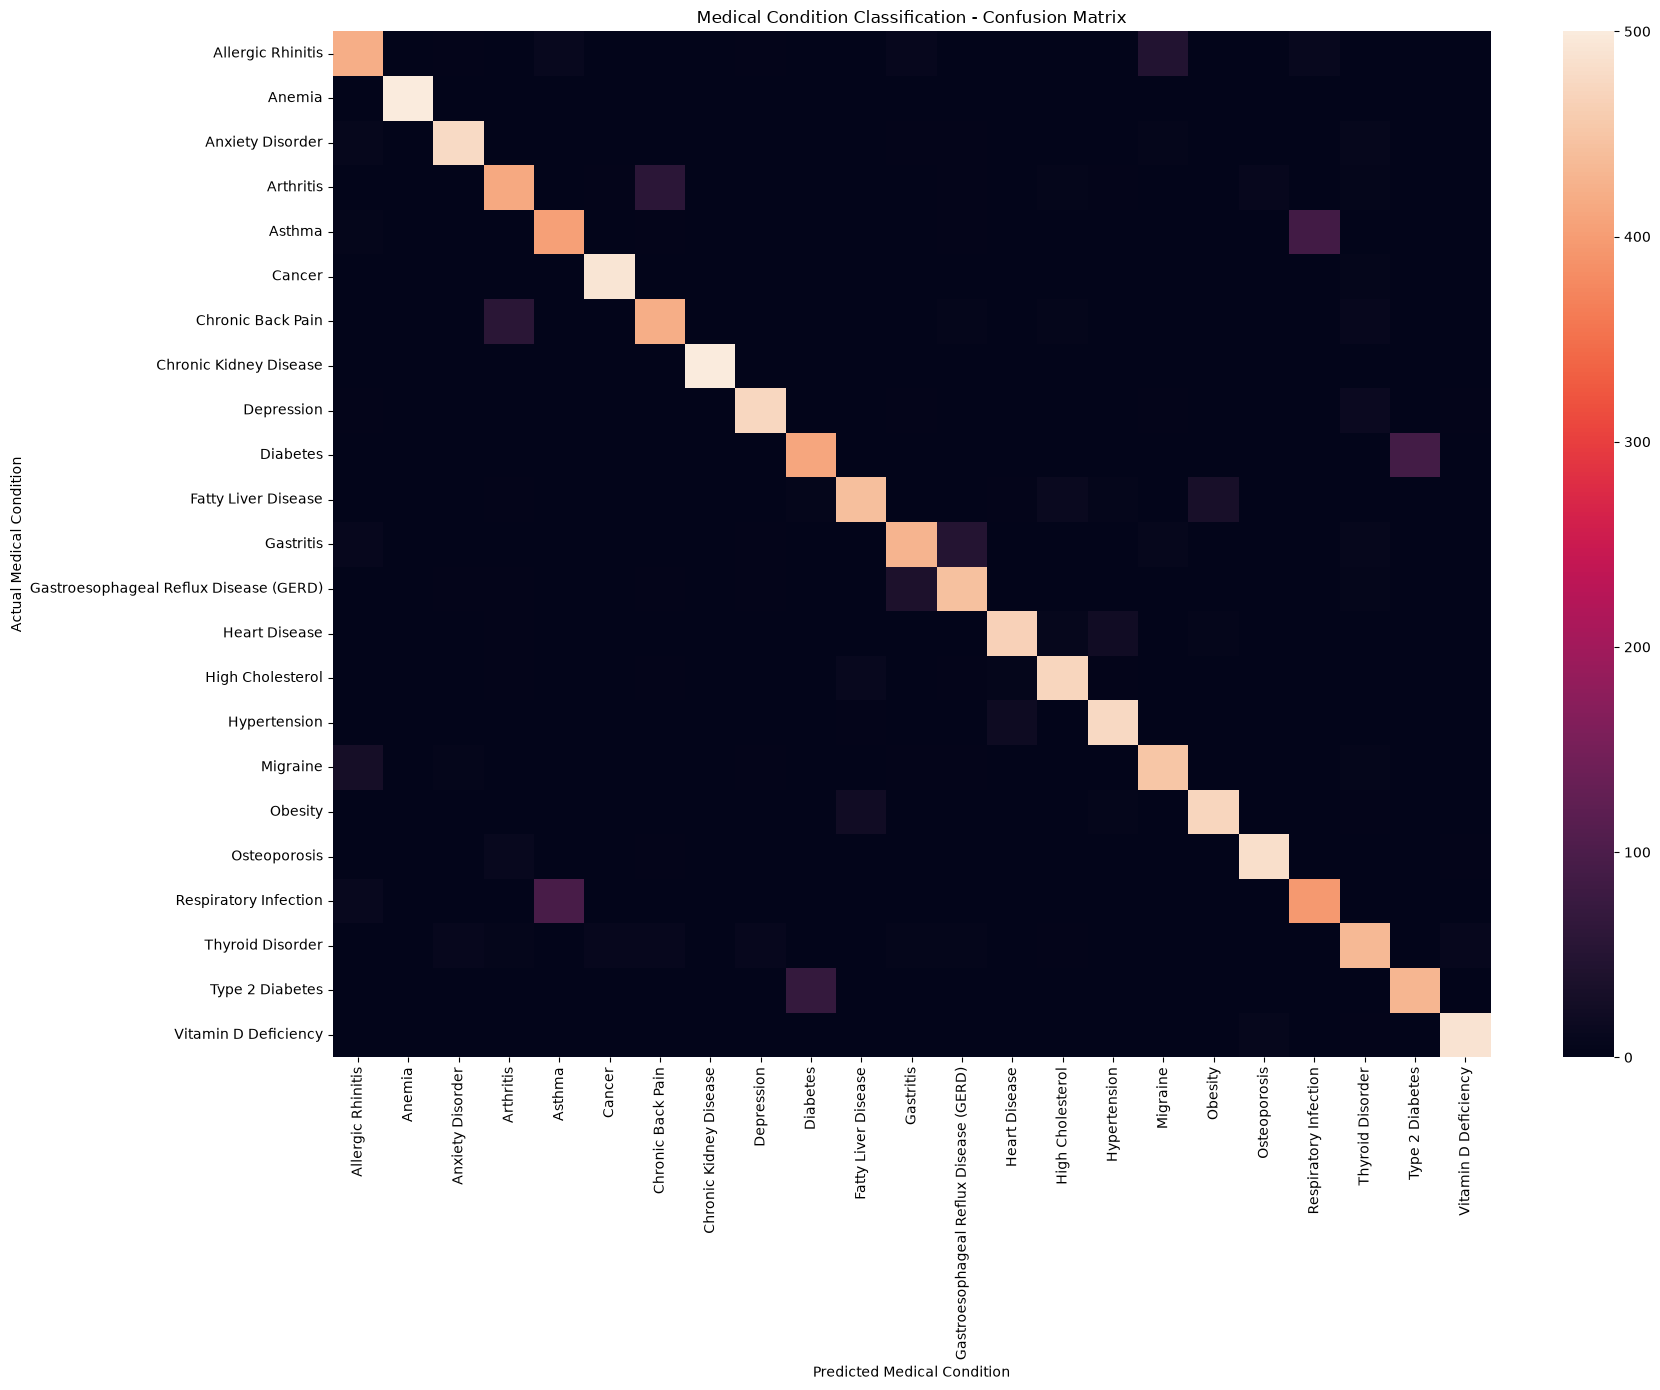

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(18, 14))

sns.heatmap(
    cm,
    annot=False,
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Medical Condition")
plt.ylabel("Actual Medical Condition")
plt.title("Medical Condition Classification - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,Age,12.259101
10,Vitamin_D,9.736779
8,Blood_Glucose,9.663208
11,Hemoglobin,9.332679
5,BMI,8.165158
6,Systolic_BP,7.631239
9,Cholesterol,6.464322
7,Diastolic_BP,3.692192
12,Creatinine,3.099368
27,Headache,2.716231


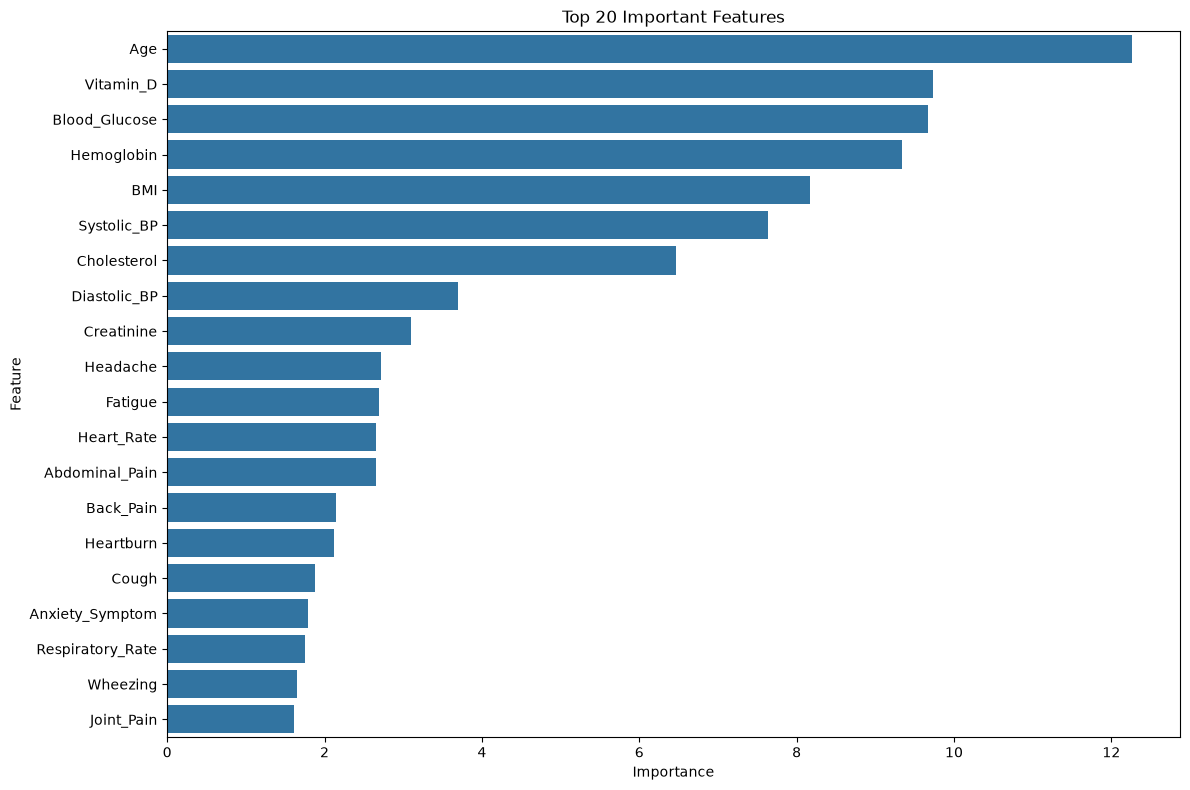

In [16]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [17]:
joblib.dump(
    model,
    "medical_condition_model.pkl"
)

print("✅ Model saved as medical_condition_model.pkl")

✅ Model saved as medical_condition_model.pkl


In [18]:
model_info = {
    "features": X.columns.tolist(),
    "categorical_features": categorical_columns,
    "target": "Medical Condition",
    "classes": model.classes_.tolist()
}

joblib.dump(
    model_info,
    "medical_model_info.pkl"
)

print("✅ Model information saved.")

✅ Model information saved.


In [19]:
loaded_model = joblib.load(
    "medical_condition_model.pkl"
)

test_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Actual Condition:")
print(y_test.iloc[0])

print("\nPredicted Condition:")
print(test_prediction[0])

Actual Condition:
High Cholesterol

Predicted Condition:
['High Cholesterol']
